In [1]:
import pypsa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import os
import pypsatopo
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import cartopy.crs as ccrs
from shapely.errors import ShapelyDeprecationWarning
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning)   

In [2]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)


costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"];

annuity = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1);

costs["capital_cost"] = (annuity + costs["FOM"] / 100) * costs["investment"]

In [3]:
os.getcwd()
os.chdir("C:/Users/Pulin/Desktop/Msc_Thesis_Greenlab_Skive")
os.getcwd()

'C:\\Users\\Pulin\\Desktop\\Msc_Thesis_Greenlab_Skive'

# Weather Data

In [4]:
# 1. Load the dataset
PV_data = pd.read_csv("Re_Ninja_PV_data_DK.csv", 
    skiprows=3, sep=None, engine='python',
    compression='infer')
# 2. Convert 'time' to datetime and remove timezone offset (+00:00)
# This makes it compatible with standard DK1/DK2 weather data
PV_data['time'] = pd.to_datetime(PV_data['time']).dt.tz_localize(None)
# 3. Set the index as a DatetimeIndex and drop the helper column
PV_data.index = pd.DatetimeIndex(PV_data['time'])
PV_data.drop(columns=['time'], inplace=True)
# 4. Clean column names (removes "Unnamed" or accidental whitespace)
PV_data.columns = PV_data.columns.str.strip()
# Display the first few rows to verify
#print(PV_data.head())

In [5]:
CF_solar = PV_data.mean(axis = 1) # average all the years

In [6]:
OnshoreWind_Data = pd.read_csv("Re_Ninja_WindOnshore_data_DK.csv",
    skiprows=3, sep=None, engine='python',
    compression='infer')

OnshoreWind_Data["time"] = pd.to_datetime(OnshoreWind_Data["time"]).dt.tz_localize(None)
OnshoreWind_Data.index = pd.DatetimeIndex(OnshoreWind_Data["time"])
OnshoreWind_Data.drop(columns = ["time"], inplace = True)
OnshoreWind_Data.columns = OnshoreWind_Data.columns.str.strip()


In [7]:
CF_wind = OnshoreWind_Data.mean(axis = 1) # average of all years for the different datasets

# Natural Gas Prices

In [8]:
current_dir = os.getcwd()
gas_file = os.path.join(current_dir, 'GasDailyBalancingPrice.xlsx')

# units is in DKK/kWh
gas_price_pre_oct_2021 = pd.read_excel("GasSystemBalanceUntil20221001.xlsx")
gas_price_pre_oct_2021.tail()

,GasDay,Created,BalanceType,Balance,ProductCode,greenZoneMin,greenZoneMax,YellowZoneMin,YellowZoneMax,GasBuyingPriceDKK,GasBuyPriceDescription,GasSellingPriceDKK,GasSellPriceDescription
15861,2022-09-30 00:00:00,2022-10-01 01:45:15,ESCB,3166032,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15862,2022-09-30 00:00:00,2022-09-30 22:45:23,ESCB,3537232,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN
15863,2022-09-30 00:00:00,2022-10-31 07:28:17,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15864,2022-09-30 00:00:00,2022-11-09 13:28:53,SCB,9310742,Valid ordinary,-3758094,12241906,-53575500,53575500,1.2558,"Adjustment of balance purchase step 1, NG-WD *...",1.2684,"Adjustment of balance sale step 1, NG-WD * ADJ..."
15865,2022-09-30 00:00:00,2022-09-30 06:46:05,ESCB,-4450243,Non valid ordinary,-3758094,12241906,-53575500,53575500,NaN,NaN,NaN,NaN


In [9]:
# 1. Clean and Deduplicate as you did
gas_price_pre_oct_2021["GasDay"] = pd.to_datetime(gas_price_pre_oct_2021["GasDay"]).dt.tz_localize(None)
gas_price_pre_oct_2021.index = pd.DatetimeIndex(gas_price_pre_oct_2021["GasDay"])
gas_price_pre_oct_2021 = gas_price_pre_oct_2021.groupby(level=0).mean(numeric_only=True)

# 2. Add a "dummy" row to ensure the LAST day gets all 24 hours
# This adds one more day at the very end of your existing index
last_day = gas_price_pre_oct_2021.index.max()
next_day = last_day + pd.Timedelta(days=1)
gas_price_pre_oct_2021.loc[next_day] = None 

# 3. Apply the 6-hour offset for the Danish Gas Day
gas_price_pre_oct_2021.index = gas_price_pre_oct_2021.index + pd.Timedelta(hours=6)

# 4. Resample and Forward Fill
# This propagates the 06:00 price through all 24 hours of that gas day
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021.resample('h').ffill()

# 5. Drop the very last hour (which belongs to the dummy day's 06:00 start)
gas_price_pre_oct_2021_hourly = gas_price_pre_oct_2021_hourly.iloc[:-1]

In [10]:
gas_price_data = pd.read_excel(gas_file)

In [11]:
# 1. Convert the 'GasDay' column to datetime and remove timezone offset
gas_price_data["GasDay"] = pd.to_datetime(gas_price_data["GasDay"]).dt.tz_localize(None)
# 2. Set the 'GasDay' column as the index
gas_price_data.index = pd.DatetimeIndex(gas_price_data["GasDay"])
# 3. Resample to hourly to match solar_pv_data (forward fill daily prices)
gas_price_hourly = gas_price_data.resample('h').ffill()

In [12]:
# EURO -> DKK exchange rate
EUR_DKK_exchangerate = (gas_price_hourly["ExchangeRateEUR_DKK"]/100)

In [13]:
gas_price_hourly["MarginalPurchasePriceEUR_MWh"] = ((gas_price_hourly["MarginalPurchasePriceDKK_kWh"]/EUR_DKK_exchangerate)*1000)
gas_price_hourly["MarginalPurchasePriceEUR_MWh"]

GasDay
2022-10-01 00:00:00    164.176696
2022-10-01 01:00:00    164.176696
2022-10-01 02:00:00    164.176696
2022-10-01 03:00:00    164.176696
2022-10-01 04:00:00    164.176696
                          ...    
2025-12-26 20:00:00     30.641750
2025-12-26 21:00:00     30.641750
2025-12-26 22:00:00     30.641750
2025-12-26 23:00:00     30.641750
2025-12-27 00:00:00     29.731466
Freq: h, Name: MarginalPurchasePriceEUR_MWh, Length: 28393, dtype: float64

In [14]:
part1 = gas_price_pre_oct_2021_hourly["GasBuyingPriceDKK"][:"2022-09-30"]*(1000/7.45)  # DKK/kwh -> EUR/MWh
part2 = gas_price_hourly["MarginalPurchasePriceEUR_MWh"] # EUR/MWh

NG_price = pd.concat([part1, part2], axis=1)

# keep='last' prioritizes data from 'part2' for the overlapping hours
NG_price = NG_price[~NG_price.index.duplicated(keep='last')].sort_index()

# 4. Fill any remaining tiny gaps (just in case)
NG_price = NG_price.resample('H').ffill()

# 1. Fill missing values in the EUR_MWh column with the DKK column values
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].fillna(NG_price["GasBuyingPriceDKK"])

# 2. Drop the original DKK column if you no longer need it
NG_price = NG_price.drop(columns=["GasBuyingPriceDKK"])

In [15]:
NG_price["MarginalPurchasePriceEUR_MWh"] = NG_price["MarginalPurchasePriceEUR_MWh"].ffill() 

# Electricity Prices

In [16]:
"full spot price data el DK1";
elspotprices = pd.read_excel("Elspotprices1999_onwards.xlsx", index_col=0, parse_dates=True) # EUR/MWh

In [17]:
"øre/kWh";
tariff_el_use = {
    "2021": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.123)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.09,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.92         # Net Tariff: Spidslast
    },
     "2022": {
        "el_transmission_tariff": 4.9,
        "el_system_tariff": 6.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.116)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 4.51,         # Net Tariff: Lavlast
        "el_tariff_high": 8.32,        # Net Tariff: Højlast
        "el_tariff_peak": 12.15         # Net Tariff: Spidslast
    },
    "2023": {
        "el_transmission_tariff": 5.8,
        "el_system_tariff": 5.4,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.16)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 2.43,         # Net Tariff: Lavlast
        "el_tariff_high": 4.80,        # Net Tariff: Højlast
        "el_tariff_peak": 7.33         # Net Tariff: Spidslast
    },
    "2024": {
        "el_transmission_tariff": 7.4,
        "el_system_tariff": 5.1,       
        "el_tax": 0.8,                 
        "el_prod_tariff": (0.3 + 0.24)/2, # (Injection_tariff + Balancing_tariff)/2
        "el_tariff_low": 0.85,         # Net Tariff: Lavlast
        "el_tariff_high": 2.54,        # Net Tariff: Højlast
        "el_tariff_peak": 5.08,         # Net Tariff: Spidslast
    }

}

In [18]:
def build_electricity_grid_price_w_tariff(Elspotprices, tariff_dict, year):
    # 1. Year Filter & Column Selection (Fixes DateParseError)
    year_str = str(year)
    spot = Elspotprices.loc[Elspotprices.index.year == int(year_str), "SpotPriceEUR"]
    
    # 2. Settings & Conversion (øre/kWh to EUR/MWh)
    d = tariff_dict[year_str]
    DKK_to_EUR_MWh = 10 / 7.45 
    
    # 3. Define Logic Windows
    hours = spot.index
    is_winter = hours.month.isin([1, 2, 3, 10, 11, 12])
    is_peak_time = hours.hour.isin(range(17, 21)) # 17:00 to 20:59
    is_day_time = hours.hour.isin(range(6, 24))   # 06:00 to 23:59

    # 4. Apply Net Tariff Levels
    net_tariff = pd.Series(d["el_tariff_low"], index=hours)
    net_tariff.loc[is_day_time] = d["el_tariff_high"]
    net_tariff.loc[is_winter & is_peak_time] = d["el_tariff_peak"]

    # 5. Calculate Final Prices
    fixed_fees = d["el_transmission_tariff"] + d["el_system_tariff"] + d["el_tax"]
    buy_price = spot + (fixed_fees + net_tariff) * DKK_to_EUR_MWh
    
    # Selling = Spot minus production costs
    sell_price = -spot + (d["el_prod_tariff"] * DKK_to_EUR_MWh)

    return buy_price, sell_price

In [19]:
import_price21, export_price21 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2021")
import_price22, export_price22 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2022")
import_price23, export_price23 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2023")
import_price24, export_price24 = build_electricity_grid_price_w_tariff(elspotprices, tariff_el_use, "2024")

# Grid Electrcity Emissions

In [20]:
import pandas as pd
import requests

def get_danish_co2_data(start_date="2023-01-01", end_date="2023-12-31"):
    # The API uses a 'Where' filter for dates. 
    # We target DK1 (West Denmark/Skive area)
    url = "https://api.energidataservice.dk/dataset/CO2Emis"
    params = {
        'filter': '{"PriceArea":["DK1"]}',
        'start': start_date,
        'end': end_date,
        'columns': 'Minutes5UTC,CO2Emission',
        'sort': 'Minutes5UTC ASC'
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    # Convert to DataFrame
    df = pd.DataFrame(data['records'])
    
    # Convert time to datetime objects and set as index
    df['Minutes5UTC'] = pd.to_datetime(df['Minutes5UTC'])
    df.set_index('Minutes5UTC', inplace=True)
    
    # The API provides 5-min data. Resample to HOURLY to match PyPSA
    # 'mean()' is used to get the average emission for that hour
    df_hourly = df['CO2Emission'].resample('h').mean()
    
    return df_hourly

# Example: Get data for your n23 year
co2_21_24 = get_danish_co2_data("2021-01-01", "2025-01-01")
print(co2_21_24.head())

# To add it to your PyPSA network:
# n23.generators_t.weight_carbon = co2_2023.values

Minutes5UTC
2020-12-31 23:00:00    190.833333
2021-01-01 00:00:00    196.000000
2021-01-01 01:00:00    168.166667
2021-01-01 02:00:00    160.083333
2021-01-01 03:00:00    161.083333
Freq: h, Name: CO2Emission, dtype: float64


In [21]:
def plot_pypsa_heatmap(data, title="PyPSA Heatmap", unit="Value", cmap="viridis", ax=None, vmin=None, vmax=None):
    """
    Added vmin and vmax for manual scale control.
    """
    if isinstance(data, pd.DataFrame):
        plot_data = data.mean(axis=1)
    else:
        plot_data = data

    df = plot_data.to_frame(name="values")
    df["date"] = df.index.date
    df["hour"] = df.index.hour
    
    pivot = df.pivot_table(index="date", columns="hour", values="values", aggfunc='mean')

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    # Pass vmin and vmax here
    sns.heatmap(pivot, cmap=cmap, cbar_kws={'label': unit}, ax=ax, 
                rasterized=True, vmin=vmin, vmax=vmax)
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Date")

## Helper Functions for Network

In [58]:
def add_carriers(n):
    #n.add("Carrier",'electricity grid im')
    #n.add("Carrier","electricity grid ex") 
    n.add("Carrier","onshorewind")
    n.add("Carrier","solar")
    n.add("Carrier","electric boiler")
    #n.add("Carrier","Rondo charge")
    #n.add("Carrier","Rondo store")
    #n.add("Carrier","Rondo discharge")
    n.add("Carrier","heat")
    n.add("Carrier","battery storage")
    n.add("Carrier","electricity")
    n.add("Carrier","gas") # co2_emissions=0.206tonnes/MWh   # for NG boiler # Assume that methane gas emits 0.198 tCO2 per MWh of thermal energy contained in the gas. 
    n.add("Carrier", "pellets", unit = "MW") 
    n.add("Carrier", "CO2", unit = "t/h") #co2_emissions=-0.164 (tCO2/MWh_pell) #for biochar # -0.164 ????
    n.add("Carrier", "pyrolysis")
    n.add("Carrier", "hydrogen")
    n.add("Carrier", "methanol")
    n.add("Carrier", "methanolisation")
    n.add("Carrier", "electrolysis")
    n.add("Carrier", "digestate")
    
    n.add("Carrier", "biomass", unit = "t/h")
    n.add("Carrier", "biochar")
    n.add("Carrier", "methane")

In [23]:
def add_skive_generators(n,s_cf,w_cf):

    # EuroWind Owns These Assets
    n.add("Generator", "Skive_Solar", carrier="solar",
        bus = "Greenlab" , # Greenlab , EuroWind
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"], 
        p_max_pu= s_cf, 
        p_nom = 30)


    n.add("Generator","Skive_Onshore_Wind", carrier="onshorewind",
        bus = "Greenlab",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu= w_cf,
        p_nom = 54)

In [24]:
def add_grid(n, price_import, price_export):
    #------ IMPORTS ----------------------------
    n.add("Generator", "Grid_Generator",
          bus="Grid_Import",
          p_nom_extendable=True,
          efficiency=1.0,
          marginal_cost=0,
          capital_cost=0.0,
          carrier="electricity")

    n.add("Link", "Imports",
          bus0="Grid_Import",
          bus1="Greenlab",   # [EuroWind or Greenlab]
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_import)

    #------- EXPORTS -----------------------
    n.add("Store", "Grid_Store",
          bus="Grid_Export",
          e_nom_extendable=True,
          capital_cost=0.0,
          standing_loss=0.0,
          carrier="electricity")

    n.add("Link", "Exports",
          bus0="Greenlab",   # [EuroWind or Greenlab]
          bus1="Grid_Export",
          p_nom=84,
          p_nom_extendable=False,
          efficiency=0.97,
          p_min_pu=0,
          p_max_pu=1.0,
          carrier="electricity",
          marginal_cost=price_export)

In [25]:
def add_battery(n,P_nom, max_t, cyclic_operation = False):
    n.add("StorageUnit",
        "Skive_Battery",
        bus="Greenlab",  # Use your electricity bus name {EuroWind, Greenlab}
        carrier="battery storage",
        max_hours= max_t,  # 22 MW * 2 h = 44 MWh
        capital_cost=costs.at["battery inverter", "capital_cost"] + 4 * costs.at["battery storage", "capital_cost"],
        
        efficiency_store = 0.90, # Charging Efficiency
        efficiency_dispatch=costs.at["battery inverter", "efficiency"], # Discharging Efficiency
        p_nom= P_nom,  # 22 MW
        p_nom_extendable=False,
        cyclic_state_of_charge=cyclic_operation)

In [26]:
"High Temprature Bus (350)";
def add_TES_rondo(n,e_nom_store = 100, p_nom_charge= 24,p_nom_discharge = 7):
    n.add("Store", "Rondo_Concrete_Heat_Storage",
        bus="TES_Rondo",
        #e_nom= e_nom_store, # MWh
        e_nom_extendable=True,
        e_nom_min = e_nom_store,
        e_nom_max = e_nom_store,
        e_cyclic=False,
        standing_loss= 1.2/100, # 1.2% per hour
        capital_cost=costs.at["Concrete-store", "capital_cost"] )      

    # "Charging of Rondo ,  El_Bus -> TES_Rondo";
    n.add("Link",
        "El_to_TES_Rondo",
        bus0="Greenlab",
        bus1="TES_Rondo",
        p_nom_extendable=True,
        p_nom_min = p_nom_charge,
        p_nom_max = p_nom_charge, 
        # p_nom = p_nom_charge, # MW
        efficiency=0.98,
        carrier = "electricity",
        capital_cost=costs.at["Concrete-charger", "capital_cost"])

    # "Discharging of Rondo , TES_Rondo -> Heat_Bus_Skive";
    n.add("Link",
        "TES_Rondo_to_Heat_Bus_Skive",
        bus0="TES_Rondo",
        bus1="Heat_Exchanger_Bus",
        #p_nom = p_nom_discharge,
        p_nom_extendable=True,
        p_nom_min = p_nom_discharge,
        p_nom_max = p_nom_discharge,
        efficiency=0.90,
        carrier = "heat",
        capital_cost=costs.at["Concrete-discharger", "capital_cost"])


# 2 Heat Exchanger hence effincecy = 0.9*0.9 = 0.81
def add_heat_exchanger(n):
    n.add("Link", "Heat_Exchanger_Rondo",
     bus0="Heat_Exchanger_Bus",
     bus1="Heat_MT", 
     carrier="heat", 
     p_nom_extendable=True , 
     efficiency=0.8)

In [27]:
"Medium Temprature (150 C)";
def  add_electric_boiler(n):
    "Boiler at Skive";
    n.add("Link","Boiler_Skive",
        bus0 = "Greenlab",
        bus1="Heat_MT",
        #p_nom = 10, # MW,
        p_nom_extendable = True,
        p_nom_min = 10,
        p_nom_max = 10,
        efficiency=0.9,
        carrier = "electric boiler",
        capital_cost=costs.at["electric boiler steam","capital_cost"],
        marginal_cost = costs.at["electric boiler steam","marginal_cost"])

In [28]:
def add_NG_boiler(n,CO2tax, NG_price):
     n.add("Generator",
        "NG grid",
        bus="NG",
        carrier="gas",
        p_nom = 6,
        capital_cost = costs.at["decentral gas boiler","capital_cost"],
        marginal_cost = NG_price + CO2tax, #0.206  tCO2/MWh *  80EUR/tC02 + VOM 1.007EUR/MWh
        p_nom_extendable=False,)

     n.add("Link","NG boiler",
        bus0="NG",
        bus1="Heat_MT",
        efficiency=0.98,
        p_nom=6,
        p_nom_extendable=False,) 

In [29]:
def add_SkyClean(n,CO2tax):  
    n.add("Generator",
        "pellets input",
        bus="pellets",
        carrier="pellets",
        p_nom_extendable=True,
        marginal_cost= 62) #€/MWh (Price of straw pellets 380 €/t

    n.add("Store",
    "pellets store",
     bus = "pellets",
     carrier = "pellets",
     e_nom_extendable = True)
    
    # straw pellets cost from 35 - 82 EUR/ton
    # LHV_pellets = 16 MJ/kg
    

    n.add("Link",
        "pyrolysis",
        bus0="pellets",
        bus1="Heat_MT",
        bus2="biochar",
        bus3 = "Greenlab",
        p_nom_extendable=False,
        p_nom=2,
        efficiency = 8.5/20, # MW , 8.2/21.7 , Heat High Temp
        efficiency2 = 9/20, # MW , 10.1/21.7 , Biochar
        efficiency3 = -0.02, # MW, auxillary power (2 %)
        carrier="pyrolysis",
        capital_cost=costs.at["biochar pyrolysis","capital_cost"]) 

    
    n.add("Link",
        "biochar sequestration",
        bus0="biochar",
        bus1="biochar sequestration",
        efficiency=1,
        p_nom_extendable = True,
        marginal_cost=-0.164*CO2tax,   #CO2 tax   or -0.164 (tCO2/MWh_pell)?  # -1  * co2_credits #-13.12eur/MWh
        carrier="biochar") 

    n.add(
        "Store",
        "biochar sequestred",
        bus="biochar sequestration",
        e_nom_extendable=True,
        e_cyclic=False,
        carrier="biochar")

In [49]:
    # Fixed Load for Biogas Plant
def biogas_plant_simple(n):

        n.add("Store","Biomass Store",
            bus = "Biogas_Feedstock",
            e_nom = 500000 ,
            e_initial = 500000, # t
            e_min_pu = 0,
            e_cyclic = False,
            carrier = "biomass",
            marginal_cost = 21) # EUR/t } Glycerine + Energy Crops + Animal Slurry

        n.add("Link",
            "BiogasPlant",
            bus0 = "Biogas_Feedstock", # input: Feedstock
            bus1 = "Greenlab", # input: electrcity
            bus2 = "Heat_MT", # input: heat
            bus3 = "pellets", # output: Pellets
            bus4 = "Biogas", # ouptut: CH4 
            bus5 = "Co2", # output: Co2
            carrier = "BiogasPlant",
            p_nom_extendable = True,
            #p_nom = 30*2.09, # t/h
            #p_min_pu = 25/30,
            p_min_pu = 0.1,
            p_max_pu = 1,
            capital_cost = costs.at["biogas","capital_cost"],
            efficiency =  -(0.02 + 0.008 + 0.02)/2.09, # el input (MW) } auxillary + dewatering + upgrading 
            efficiency2 = -(0.05 + 0.1)/2.09, # heat input (MW) } auxillary + upgrading
            efficiency3 =  0.12/2.09, # Pellets output (MW)) 
            efficiency4  = 1/2.09,  # Biogas (CH4) output (MW)
            efficiency5 = 0.1/2.09, # co2 (t/h)
        )

        
        n.add("Store", "Biogas_Store",
            bus = "Biogas",
            marginal_cost = 0,
            carrier = "methane",
            e_nom_extendable = True,)

        n.add("Store", "Co2_Store",
        bus = "Co2",
        carrier = "CO2",
        e_nom_extendable = True,
        )

        # 200 GWh, Annualy
        n.add("Load", "CH4_Demand",
        bus = "Biogas",
        p_set = 200*1e3/len(n.snapshots),
        carrier = "methane_demand")

In [31]:
"Adding Electrolyser"
def add_electrolyser(n, P_elec):
    n.add("Link",
    "Electrolyser",
    bus0 = "Greenlab",
    bus1 = "H2_Bus",
    p_nom = P_elec,
    p_min = P_elec,
    p_max = P_elec,
    p_nom_extendable = True,
    carrier = "electrolysis",
    p_min_pu = 0.15,
    #p_nom_min = , 
    #p_nom_max = ,
    capital_cost = costs.at["Alkaline electrolyzer medium size", "capital_cost"],
    marginal_cost = costs.at["Alkaline electrolyzer medium size", "marginal_cost"],
    efficiency = 0.6,)

    n.add("Store",
    "H2_Storage",
    bus = "H2_Bus",
    capital_cost = costs.at["hydrogen storage tank type 1 including compressor", "capital_cost"],
    e_nom_extendable = True,
    carrier = "hydrogen",
    e_cylic = False)

In [32]:
def add_methanolisation(n, p_min):
  
    n.add("Link",
     "methanolisation",
     bus0 = "H2_Bus",
     bus1 = "methanol_bus",
     bus2 = "Greenlab",
     bus3 = "Co2",  # Co2 from byproduct of biogas plant
     #p_nom = 10, # 10 MW methanol plant,
     p_nom_extendable = True,
     p_min_pu = p_min,
     carrier = "methanolisation",
     capital_cost = costs.at["methanolisation", "capital_cost"]*eff_h2,
     efficiency = eff_h2, # 0.87 , methanol output 
     efficiency2 = -costs.at["methanolisation", "electricity-input"]*eff_h2, # - 0.23 , electricty input
     efficiency3 = -costs.at["methanolisation", "carbondioxide-input"]*eff_h2 , # - 0.218 t/h , Co2 input
     )
 
    n.add("Store",
    "methanol storage",
    bus="methanol_bus",
    carrier="methanol",
    capital_cost=costs.at["General liquid hydrocarbon storage (crude)", "capital_cost"] / (15.6 * 1000 / 3600),
    e_nom_extendable=True,
    e_cyclic=False,)

In [33]:
def rondo_constraints(n, snapshots):
        """
        Custom constraint to keep Rondo Power = Ratio * Rondo Energy
        """
        model = n.model
        # Get variables
        e_nom = model.variables["Store-e_nom"].loc["Rondo_Concrete_Heat_Storage"]
        p_nom_charge = model.variables["Link-p_nom"].loc["El_to_TES_Rondo"]
        p_nom_discharge = model.variables["Link-p_nom"].loc["TES_Rondo_to_Heat_Bus_Skive"]

        # Add constraints (Ratio based on 24/100 and 7/100)
        model.add_constraints(p_nom_charge - 0.24 * e_nom == 0, name="Rondo_charge_ratio")
        model.add_constraints(p_nom_discharge - 0.07 * e_nom == 0, name="Rondo_discharge_ratio")

In [50]:
def build_network(CO2_tax, p_import, p_export, NG_price, horizon, overlap):
    n = pypsa.Network()
    # Set snapshots based on the Natural Gas price index
    n.set_snapshots(NG_price.index)

    
    # Align time-series data to snapshots
    s_cf = CF_solar.loc[n.snapshots].values
    w_cf = CF_wind.loc[n.snapshots].values
    p_import = p_import.loc[n.snapshots].values
    p_export = p_export.loc[n.snapshots].values

    add_carriers(n)

    n.add("Carrier","BiogasPlant")
    n.add("Carrier", "methane_demand", units = "MW")


    n.add("Bus", "Greenlab", carrier="electricity")

    n.add("Bus", "Grid_Import", carrier="electricity")
    n.add("Bus", "Grid_Export", carrier="electricity")

    n.add("Bus", "NG", carrier="gas")

     # Heat & Solids
    n.add("Bus", "Heat_Exchanger_Bus", carrier="heat")
    n.add("Bus", "TES_Rondo", carrier="heat")
    n.add("Bus", "Heat_MT", carrier="heat")
    #n.add("Bus", "Digestate", carrier = "digestate")
    
    #n.add("Bus", "H2_Bus", carrier="hydrogen")
    n.add("Bus", "Biogas_Feedstock", carrier="biomass")
    n.add("Bus", "pellets", carrier="pellets")
    n.add("Bus", "Biogas", carrier="methane")
    n.add("Bus", "Co2", carrier="CO2")

    #n.add("Bus", "CH4_Demand", carrier = "methane_demand")
    

    add_grid(n, price_import = p_import, price_export = p_export)

    n.add("Bus", "biochar", carrier="biochar")
    n.add("Bus", "biochar sequestration", carrier="biochar")
    #n.add("Bus", "methanol_bus", carrier = "methanol")

    add_battery(n, P_nom=22, max_t=2, cyclic_operation=False)
    add_skive_generators(n, s_cf, w_cf)

    # Heating & Other Technologies
    add_TES_rondo(n, e_nom_store=100, p_nom_charge=24, p_nom_discharge=7)
    add_heat_exchanger(n)
    add_electric_boiler(n)
    add_NG_boiler(n, CO2_tax, NG_price)

    biogas_plant_simple(n)
    #digestate_treatment(n)
    #add_electrolyser(n, P_elec = 12)
    add_SkyClean(n, CO2tax = 0)
    #add_methanolisation(n, p_min = 0.1)

    # --- Solving Section ---
    if horizon is not None:
        # Rolling Horizon Optimization
        n.optimize.optimize_with_rolling_horizon(
            assign_all_duals = True,
            solver_name="gurobi", 
            horizon=horizon, overlap = overlap)
    else:
        # Full Year Optimization
        n.optimize(assign_all_duals = True,
            solver_name="gurobi",)

    return n

In [35]:
def fix_capacities(n):
    """
    Transfers optimized capacities to p_nom and sets extendable to False.
    """
    # 1. Update Links (BiogasPlant, Electrolyzers, Methanolisation, etc.)
    if not n.links.empty:
        n.links.p_nom = n.links.p_nom_opt
        n.links.p_nom_extendable = False

    # 2. Update Generators (Solar, Wind, etc. if extendable)
    if not n.generators.empty:
        n.generators.p_nom = n.generators.p_nom_opt
        n.generators.p_nom_extendable = False

    # 3. Update Storage Units (Batteries)
    if not n.storage_units.empty:
        n.storage_units.p_nom = n.storage_units.p_nom_opt
        n.storage_units.p_nom_extendable = False

    # 4. Update Stores (Methane, H2, CO2, Biomass)
    if not n.stores.empty:
        n.stores.e_nom = n.stores.e_nom_opt
        n.stores.e_nom_extendable = False
        
    return n

In [51]:
n21 = build_network(CO2_tax = 80, p_import = import_price21, p_export = export_price21, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2021"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 10.63it/s]
INFO:linopy.io: Writing time: 6.42s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 9246 iterations and 17.30 seconds (15.83 work units)


INFO:gurobipy:Solved in 9246 iterations and 17.30 seconds (15.83 work units)


Optimal objective  1.089388487e+07


INFO:gurobipy:Optimal objective  1.089388487e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 280142 primals, 621552 duals
Objective: 1.09e+07
Solver model: available
Solver message: 2



In [52]:
n22 = build_network(CO2_tax = 80, p_import = import_price22, p_export = export_price22, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2022"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 10.37it/s]
INFO:linopy.io: Writing time: 6.43s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 11155 iterations and 12.15 seconds (6.84 work units)


INFO:gurobipy:Solved in 11155 iterations and 12.15 seconds (6.84 work units)


Optimal objective -4.373174942e+06


INFO:gurobipy:Optimal objective -4.373174942e+06
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 280334 primals, 621978 duals
Objective: -4.37e+06
Solver model: available
Solver message: 2



In [53]:
n23 = build_network(CO2_tax = 80, p_import = import_price23, p_export = export_price23, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2023"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 10.30it/s]
INFO:linopy.io: Writing time: 6.46s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 17877 iterations and 11.03 seconds (3.34 work units)


INFO:gurobipy:Solved in 17877 iterations and 11.03 seconds (3.34 work units)


Optimal objective  1.013478109e+07


INFO:gurobipy:Optimal objective  1.013478109e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 280334 primals, 621978 duals
Objective: 1.01e+07
Solver model: available
Solver message: 2



In [54]:
n24 = build_network(CO2_tax = 80, p_import = import_price24, p_export = export_price24, NG_price =  NG_price["MarginalPurchasePriceEUR_MWh"]["2024"], horizon = None, overlap = None)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 10.09it/s]
INFO:linopy.io: Writing time: 6.57s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2745017


INFO:gurobipy:Set parameter LicenseID to value 2745017


...

INFO:gurobipy:


Solved in 7319 iterations and 12.19 seconds (4.87 work units)


INFO:gurobipy:Solved in 7319 iterations and 12.19 seconds (4.87 work units)


Optimal objective  1.198108333e+07


INFO:gurobipy:Optimal objective  1.198108333e+07
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 281102 primals, 623682 duals
Objective: 1.20e+07
Solver model: available
Solver message: 2



Text(0.5, 1.0, '2 MW Pyrolysis Plant')

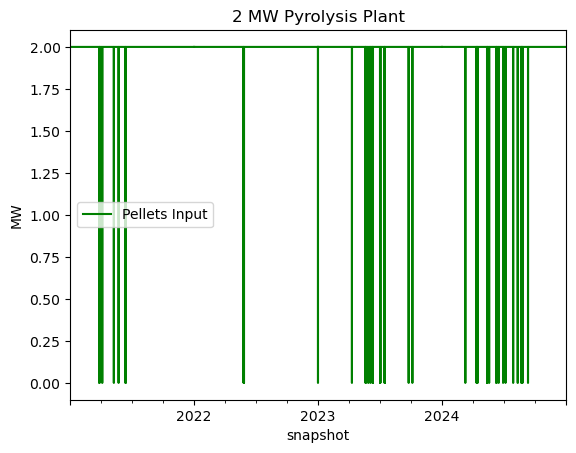

In [71]:
n21.links_t.p0["pyrolysis"].plot(color = "green", label = "Pellets Input")
plt.legend()
n22.links_t.p0["pyrolysis"].plot(color = "green")
n23.links_t.p0["pyrolysis"].plot(color = "green")
n24.links_t.p0["pyrolysis"].plot(color = "green")
plt.ylabel("MW")
plt.title("2 MW Pyrolysis Plant")

Text(0.5, 1.0, '2 MW Pyrolysis Plant')

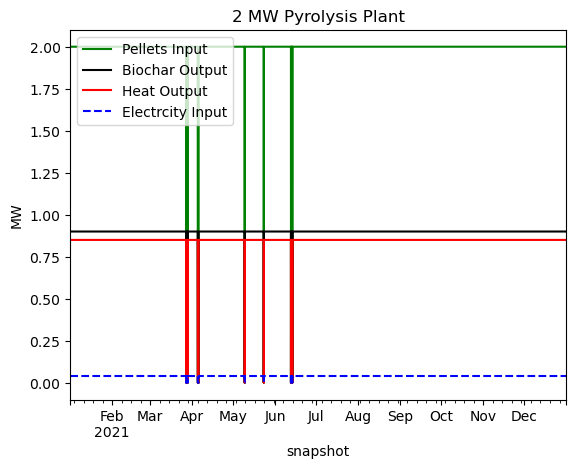

In [81]:
n21.links_t.p0["pyrolysis"].plot(color = "green", label = "Pellets Input")
(-n21.links_t.p2["pyrolysis"]).plot(color = "black", label = "Biochar Output")
(-n21.links_t.p1["pyrolysis"]).plot(color = "red", label = "Heat Output")
n21.links_t.p3["pyrolysis"].plot(color = "blue", label = "Electrcity Input",linestyle = "--")
plt.ylabel("MW")
plt.legend()
plt.title("2 MW Pyrolysis Plant")

Text(0.5, 1.0, 'Pellets Output Biogas Plant')

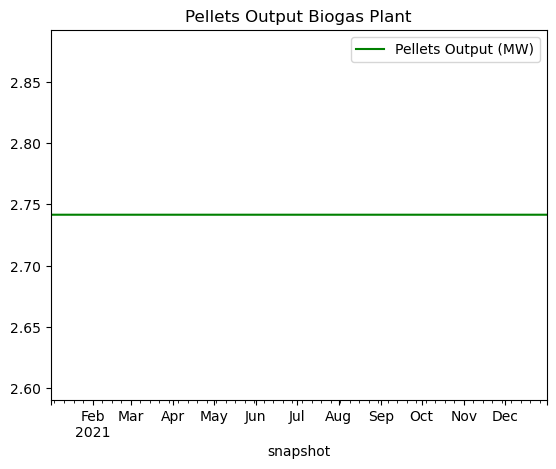

In [99]:
(-n21.links_t.p3["BiogasPlant"]).plot(color = "green",label = "Pellets Output (MW)")
plt.legend()
plt.title("Pellets Output Biogas Plant")

<Axes: xlabel='snapshot'>

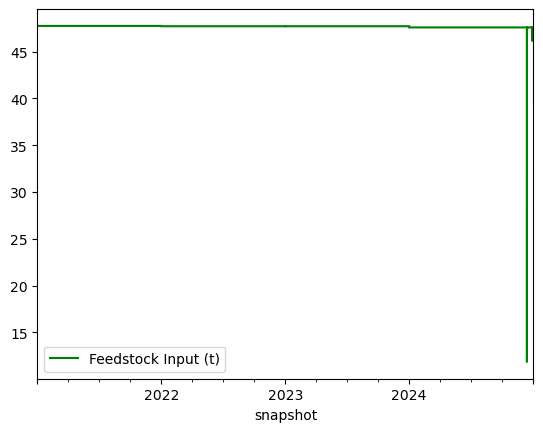

In [94]:
n21.links_t.p0["BiogasPlant"].plot(color = "green",label = "Feedstock Input (t)")
plt.legend()
n22.links_t.p0["BiogasPlant"].plot(color = "green",label = "Feedstock Input (t)")
n23.links_t.p0["BiogasPlant"].plot(color = "green",label = "Feedstock Input (t)")
n24.links_t.p0["BiogasPlant"].plot(color = "green",label = "Feedstock Input (t)")

In [129]:
n21.statistics.opex()/1e6

component  carrier        
Generator  gas                0.437888
           onshorewind        0.202360
           solar              0.000406
Link       electric boiler    0.016988
           electricity       -9.535685
Store      biomass            8.778000
Name: objective, dtype: float64

In [127]:
[n21.statistics.opex().sum()/1e6, n22.statistics.opex().sum()/1e6, n23.statistics.opex().sum()/1e6, n24.statistics.opex().sum()/1e6]

[-0.10004297375000082, -15.36034050768, -0.8523844740900006, 1.01998622011]

<Axes: ylabel='component,carrier'>

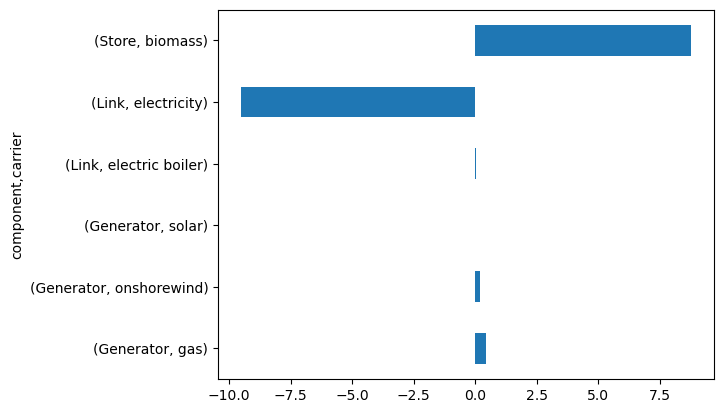

In [116]:
(n21.statistics.opex()/1e6).plot.barh()

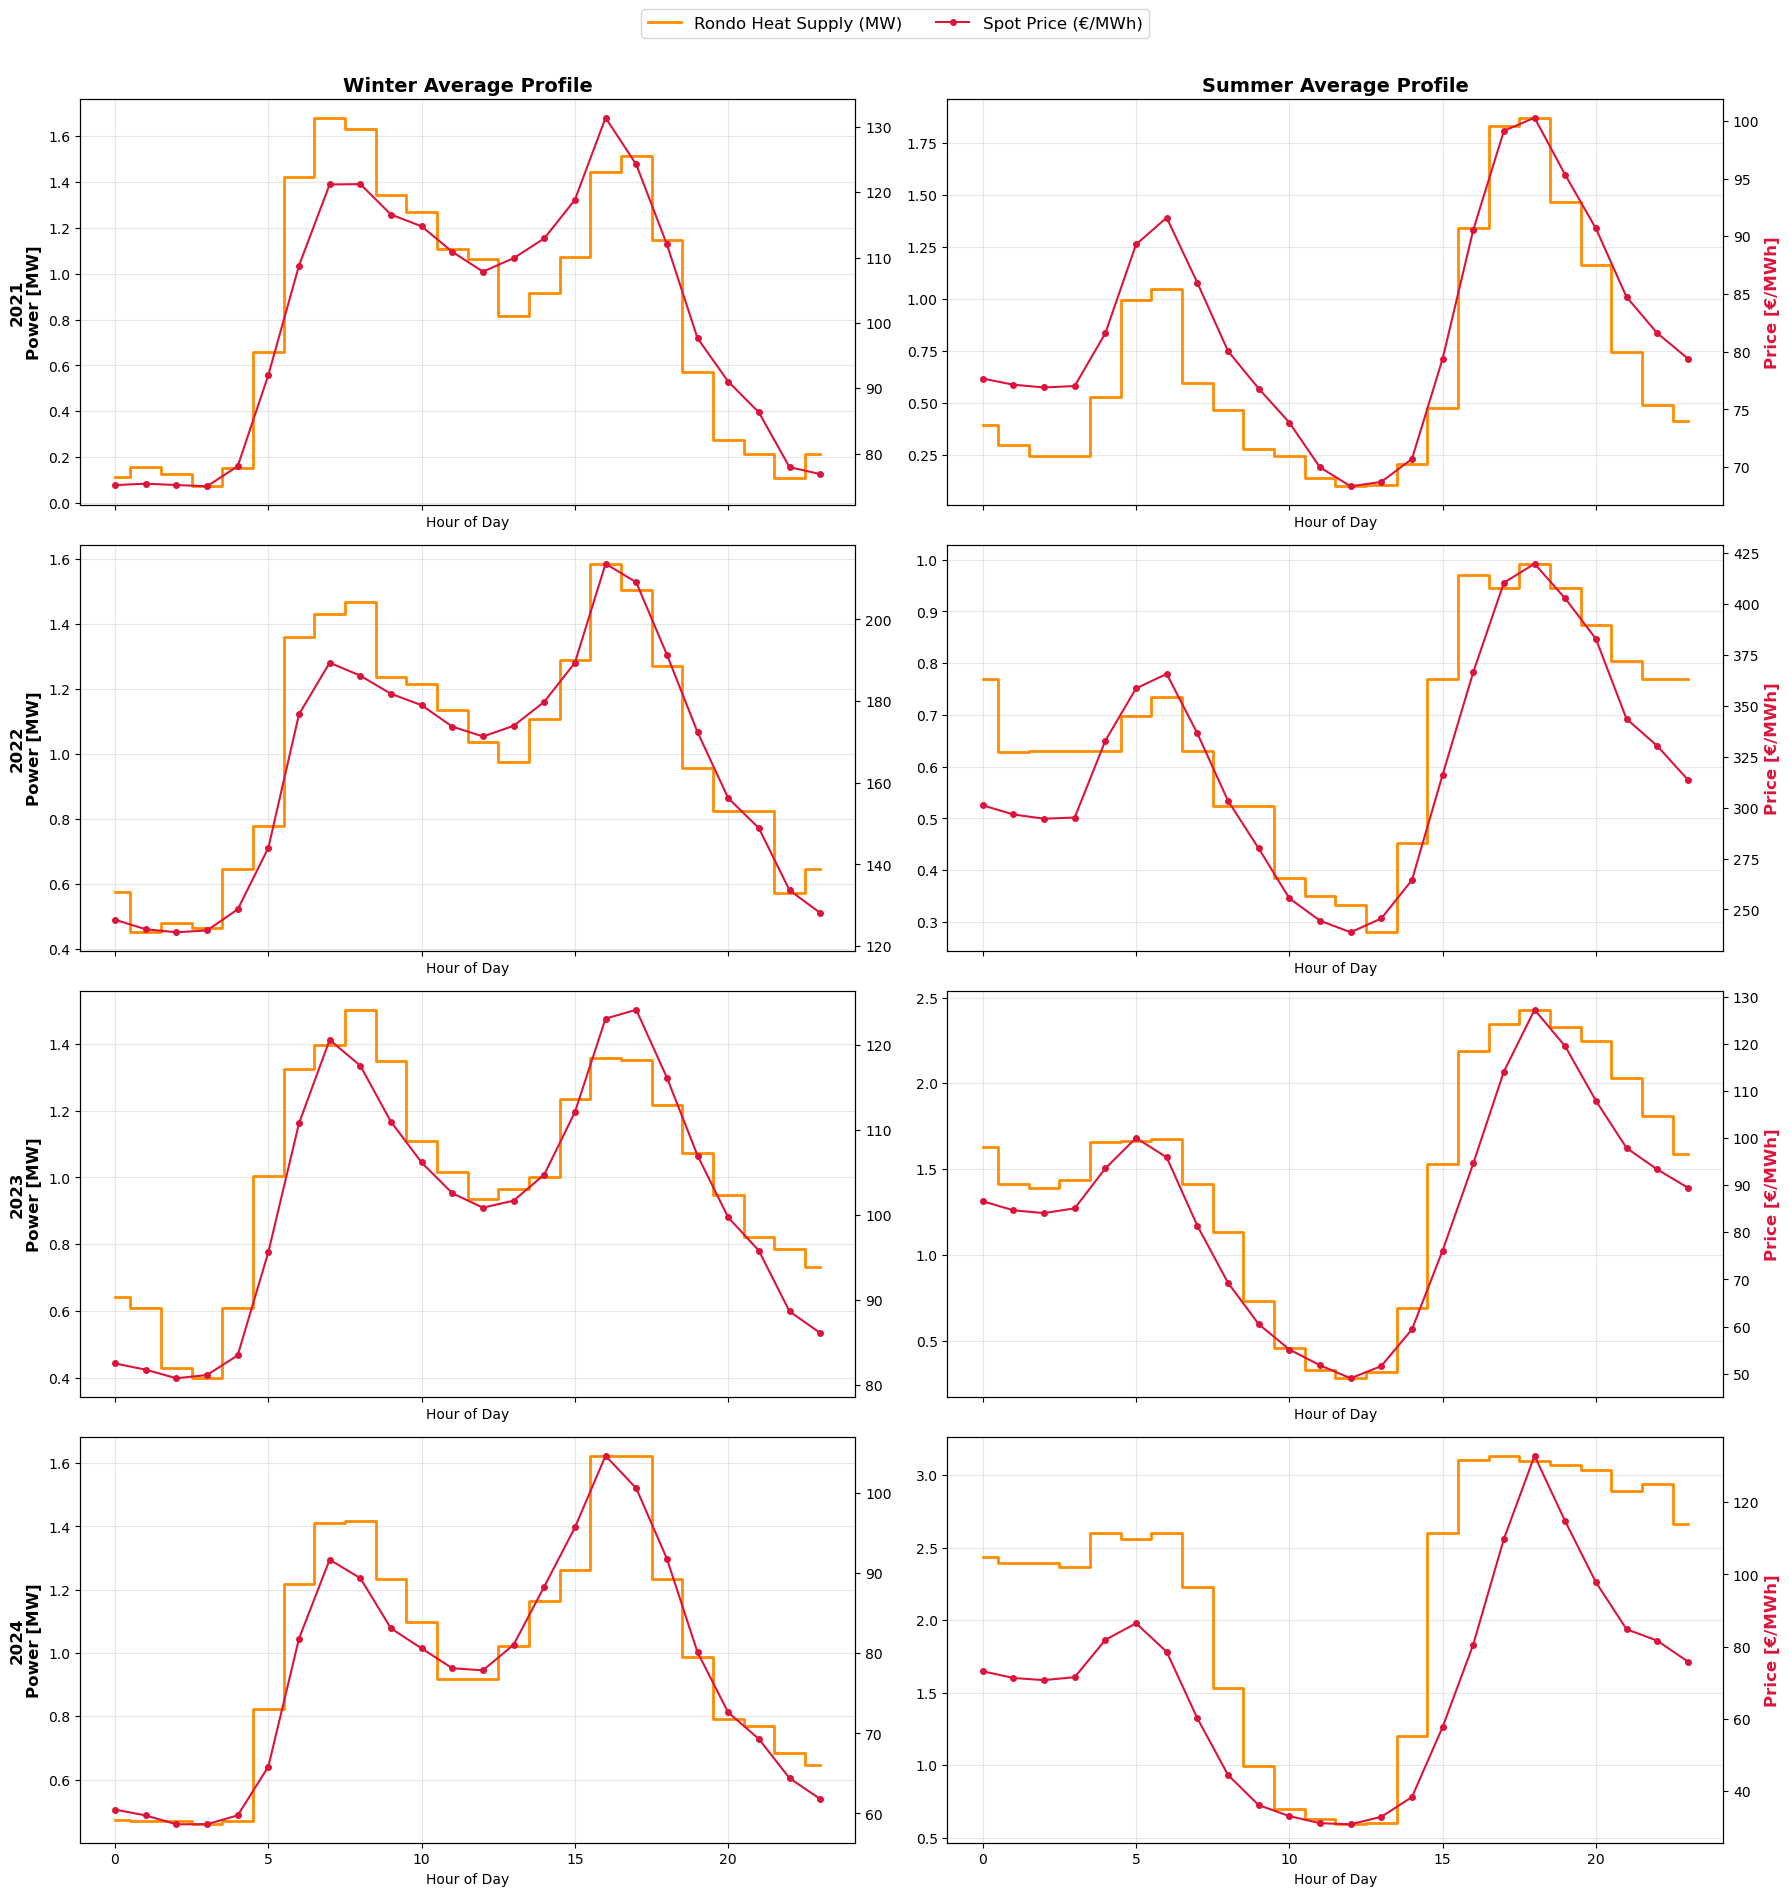

In [120]:
def plot_seasonal_profiles(networks, year_labels):
    fig, axes = plt.subplots(len(networks), 2, figsize=(18, 5 * len(networks)), sharex=True)
    
    for i, (label, n) in enumerate(zip(year_labels, networks)):
        # 1. Extract and Prep Data
        df = pd.DataFrame({
            'Price': n.buses_t.marginal_price["Greenlab"],
            #'Battery': n.storage_units_t.p["Skive_Battery"],
            'Rondo_Heat': n.links_t.p0["Heat_Exchanger_Rondo"]
        })
        df['hour'] = df.index.hour
        df['month'] = df.index.month

        # 2. Filter Seasons
        winter = df[df['month'].isin([12, 1, 2])].groupby('hour').mean()
        summer = df[df['month'].isin([6, 7, 8])].groupby('hour').mean()

        for j, (data, season) in enumerate(zip([winter, summer], ["Winter", "Summer"])):
            ax = axes[i, j]
            ax2 = ax.twinx() # Secondary axis for Price

            # Plot Battery (Bars) and Rondo (Step)
            #ln1 = ax.bar(data.index, data['Battery'], color='steelblue', alpha=0.4, label='Battery Dispatch (MW)')
            ln2 = ax.step(data.index, data['Rondo_Heat'], color='darkorange', label='Rondo Heat Supply (MW)', where='mid', lw=2)
            
            # Plot Price (Line)
            ln3 = ax2.plot(data.index, data['Price'], color='crimson', label='Spot Price (€/MWh)', marker='o', markersize=4)

            # Labels and Titles
            if i == 0: ax.set_title(f"{season} Average Profile", fontsize=14, fontweight='bold')
            if j == 0: ax.set_ylabel(f"{label}\nPower [MW]", fontsize=12, fontweight='bold')
            if j == 1: ax2.set_ylabel("Price [€/MWh]", fontsize=12, fontweight='bold', color='crimson')
            
            ax.set_xlabel("Hour of Day")
            ax.grid(True, alpha=0.3)
            
            # 3. Create Unified Legend
            if i == 0 and j == 0:
                #lines = [ln1, ln2[0], ln3[0]]
                lines = [ln2[0], ln3[0]]
                labels = [l.get_label() for l in lines]
                fig.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Run for your weather years
plot_seasonal_profiles([n21,n22,n23,n24], ["2021","2022","2023","2024"])

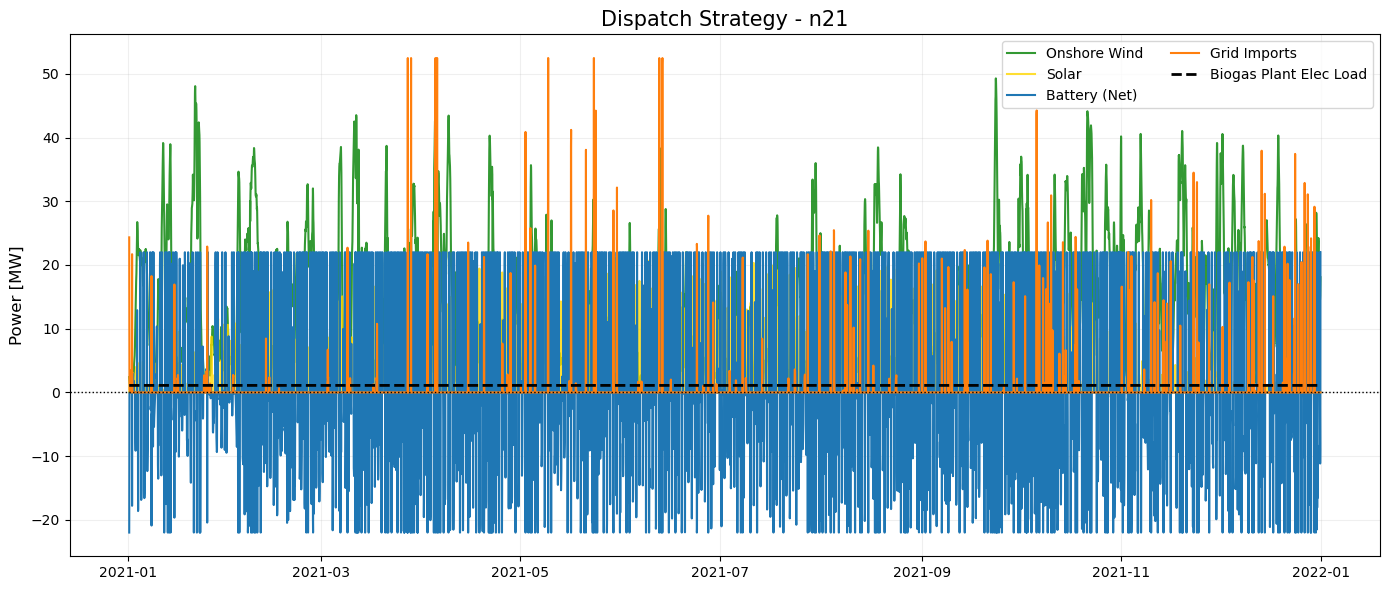

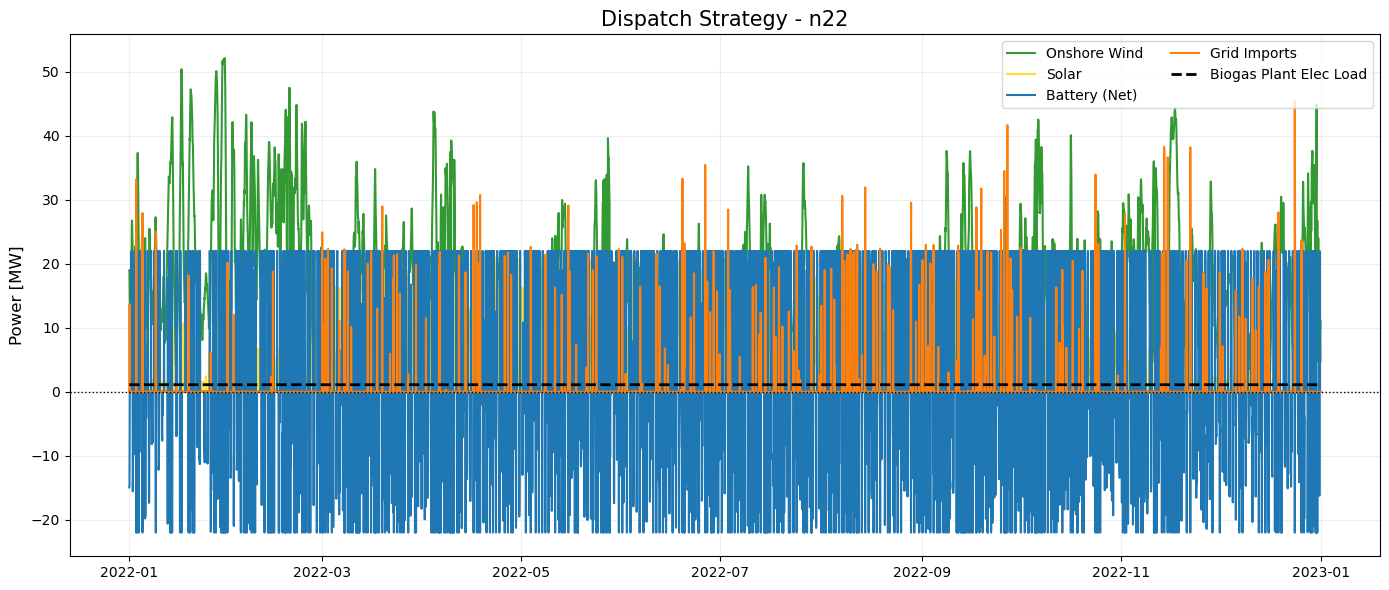

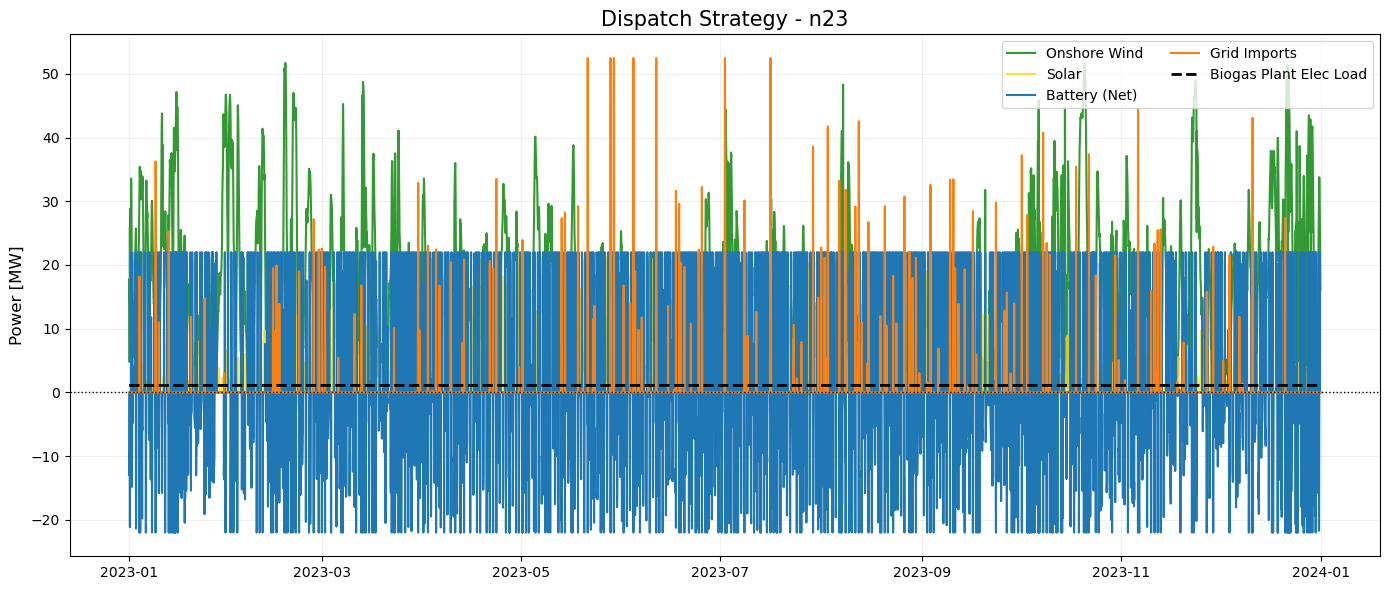

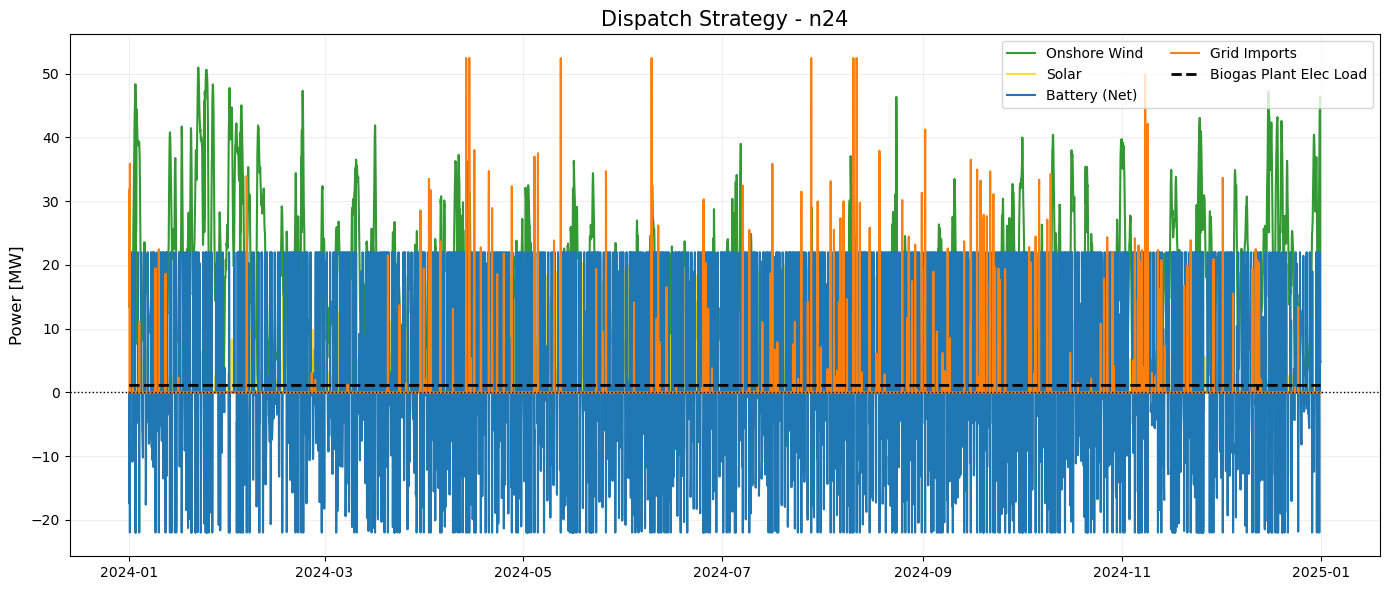

In [142]:
import matplotlib.pyplot as plt

networks = {"n21":n21,"n22": n22, "n23": n23, "n24": n24}

for name, net in networks.items():
    # 1. Define time range
    snapshots = net.snapshots

    # 2. Extract Data
    onwind = net.generators_t.p.loc[snapshots, "Skive_Onshore_Wind"]
    solar = net.generators_t.p.loc[snapshots, "Skive_Solar"]
    
    # Storage (Positive = discharging, Negative = charging)
    battery = net.storage_units_t.p.loc[snapshots, "Skive_Battery"]
    
    # Grid Imports (Ensure this matches your Link name for imports)
    grid = net.links_t.p0.loc[snapshots, "Imports"] 
    
    # FIXED: The electrical load is the p1 of the BiogasPlant.
    # We multiply by -1 because p1 is negative for inputs.
    biogas_elec_load = net.links_t.p1.loc[snapshots, "BiogasPlant"]

    # 3. Plotting
    plt.figure(figsize=(14, 6))
    
    plt.plot(onwind, label="Onshore Wind", color="green", alpha=0.8)
    plt.plot(solar, label="Solar", color="gold", alpha=0.8)
    plt.plot(battery, label="Battery (Net)", color="tab:blue")
    plt.plot(grid, label="Grid Imports", color="tab:orange")
    
    # We plot the load as a dashed line
    plt.plot(biogas_elec_load, label="Biogas Plant Elec Load", color="black", linestyle="--", linewidth=2)

    # Formatting
    plt.title(f"Dispatch Strategy - {name}", fontsize=15)
    plt.ylabel("Power [MW]", fontsize=12)
    plt.axhline(0, color='black', linewidth=1, linestyle=':')
    plt.legend(loc='upper right', ncol=2)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    
    plt.show()

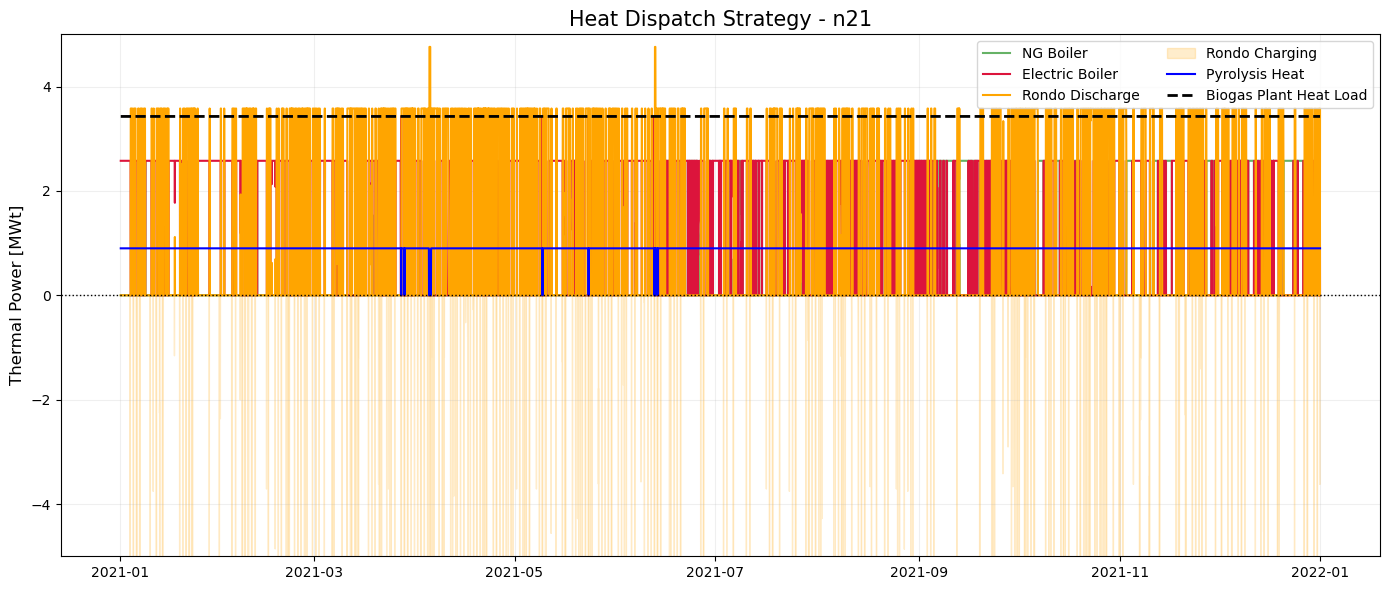

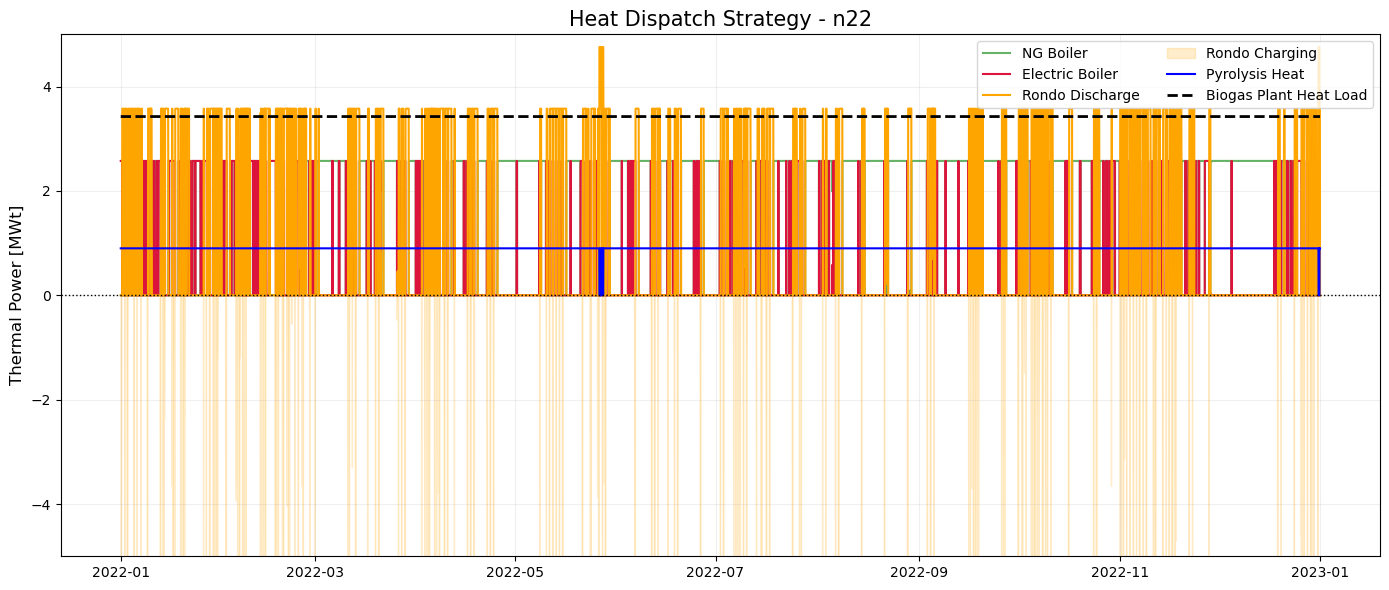

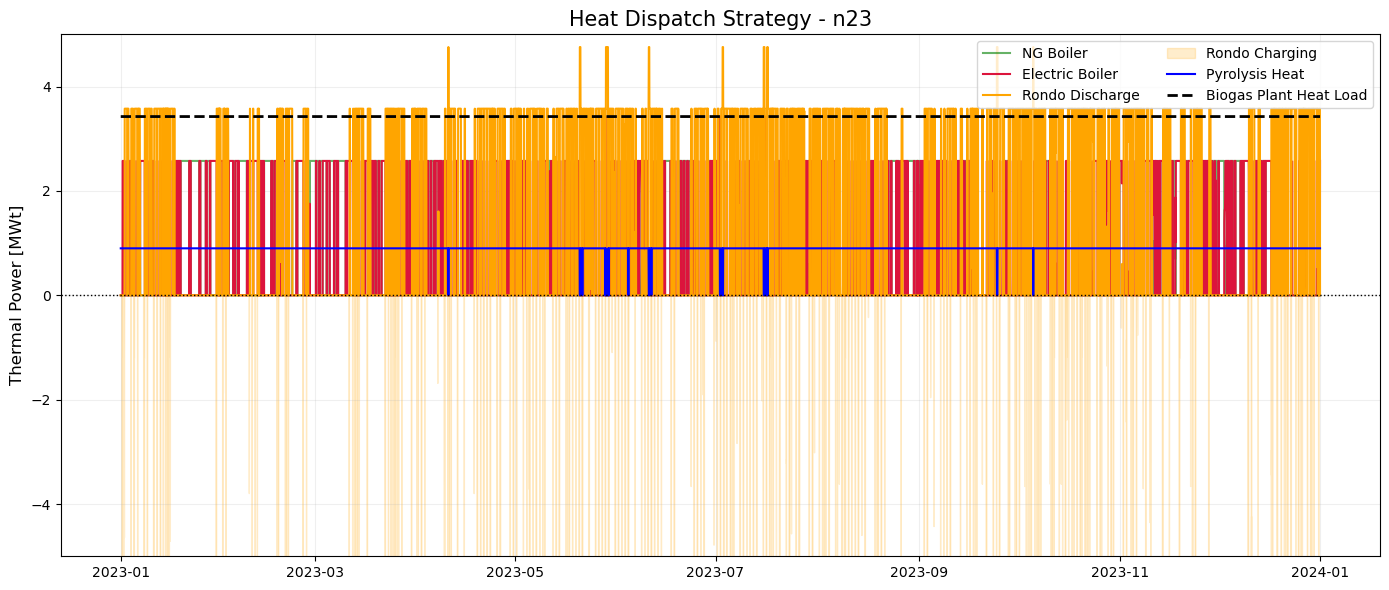

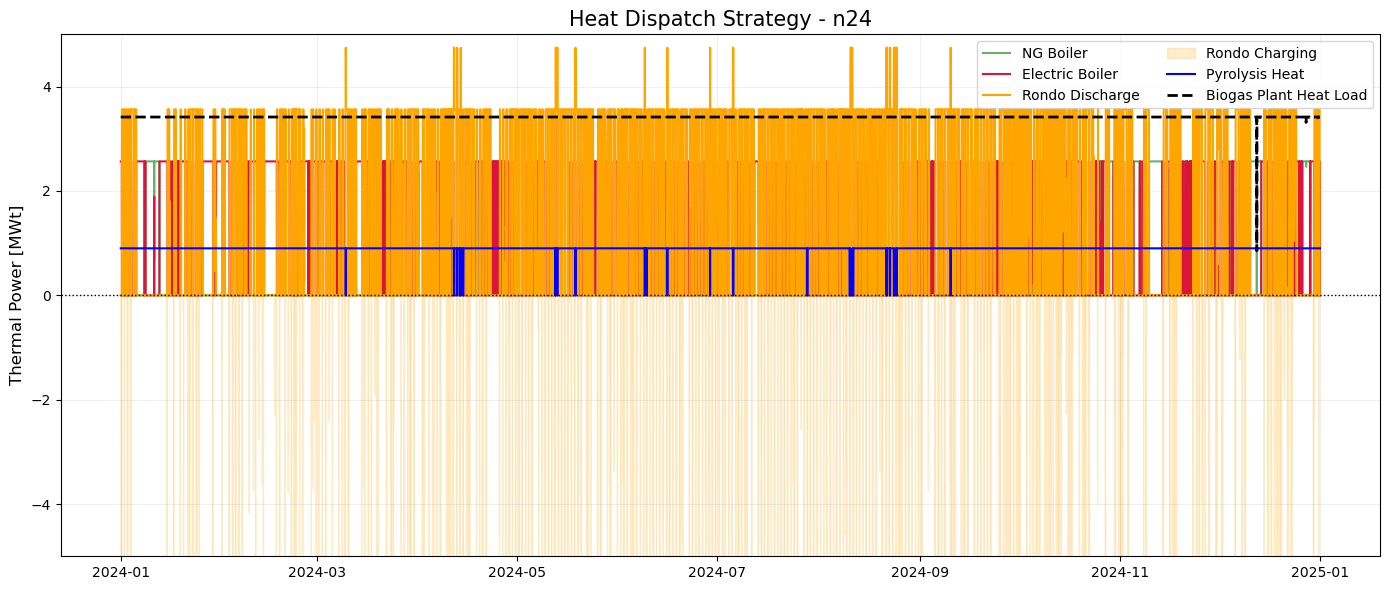

In [151]:
import matplotlib.pyplot as plt

networks = {"n21":n21,"n22": n22, "n23": n23, "n24": n24}

for name, net in networks.items():
    snapshots = net.snapshots # 1 week

    # 1. Extract Heat Demand (p2 of BiogasPlant)
    # Efficiency was -0.05/2.09, so p2 will be negative.
    biogas_heat_load = net.links_t.p2.loc[snapshots, "BiogasPlant"]

    # 2. Extract Heat Supply Technologies
    # For links, p1 is usually the output bus for heat in your setup
    el_boiler = -net.links_t.p1.loc[snapshots, "Boiler_Skive"]
    ng_boiler = -net.links_t.p1.loc[snapshots, "NG boiler"]
    
    # Pyrolysis/SkyClean heat output (Check your bus index for heat output)
    pyrolysis_heat = -net.links_t.p2.loc[snapshots, "pyrolysis"] 

    # Rondo TES (Positive = Discharging heat to the bus)
    rondo_discharge = net.stores_t.p.loc[snapshots, "Rondo_Concrete_Heat_Storage"].clip(lower=0)
    rondo_charge = net.stores_t.p.loc[snapshots, "Rondo_Concrete_Heat_Storage"].clip(upper=0)

    # 3. Plotting
    plt.figure(figsize=(14, 6))
    
    plt.plot(ng_boiler, label="NG Boiler", color="green", alpha=0.6)
    plt.plot(el_boiler, label="Electric Boiler", color="crimson")
    plt.plot(rondo_discharge, label="Rondo Discharge", color="orange")
    plt.fill_between(snapshots, 0, rondo_charge, color="orange", alpha=0.2, label="Rondo Charging")
    plt.plot(pyrolysis_heat, label="Pyrolysis Heat", color="blue")
    
    # The Heat Load line
    plt.plot(biogas_heat_load, label="Biogas Plant Heat Load", color="black", linestyle="--", linewidth=2)

    plt.title(f"Heat Dispatch Strategy - {name}", fontsize=15)
    plt.ylabel("Thermal Power [MWt]", fontsize=12)
    plt.axhline(0, color='black', linewidth=1, linestyle=':')
    plt.legend(loc='upper right', ncol=2)
    plt.grid(alpha=0.2)
    plt.ylim(-5,5)
    plt.tight_layout()
    
    plt.show()

In [152]:
def plot_heat_production(n, title="Annual Heat Production"):
    """
    Plots the annual heat production for RONDO, Electric Boiler, 
    NG Boiler, and Pyrolysis from a PyPSA network.
    """
    # 1. Define the links we are looking for
    target_links = {
        "RONDO": "Heat_Exchanger_Rondo",
        "Electric Boiler": "Boiler_Skive",
        "NG Boiler": "NG boiler",
        "Pyrolysis": "pyrolysis"
    }
    
    # 2. Extract values safely (handles missing links with 0.0)
    data = {}
    for label, link_name in target_links.items():
        if link_name in n.links.index:
            # Note: we use .get() or check existence to avoid KeyErrors
            # Summing p1 (output) and converting MW -> GWh
            data[label] = (-n.links_t.p1[link_name].sum()) / 1e3
        else:
            data[label] = 0.0
            
    annual_heat = pd.Series(data)
    total_gwh = annual_heat.sum()
    
    # Avoid division by zero if network is empty/unsolved
    if total_gwh == 0:
        print("Warning: Total heat production is 0. Check if the network is solved.")
        return
    
    # 3. Aesthetics & Sorting
    nice_colors = {'RONDO': '#FFB74D', 'Electric Boiler': '#64B5F6', 
                   'NG Boiler': '#E57373', 'Pyrolysis': '#81C784'}
    
    annual_heat_sorted = annual_heat.sort_values(ascending=False)
    plot_colors = [nice_colors[idx] for idx in annual_heat_sorted.index]
    
    # 4. Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(annual_heat_sorted.index, annual_heat_sorted.values, 
                  color=plot_colors, edgecolor='white', linewidth=1)

    # 5. Data Labels
    for bar in bars:
        height = bar.get_height()
        label_idx = annual_heat_sorted.index[bars.index(bar)]
        pct = (height / total_gwh * 100)
        
        ax.text(bar.get_x() + bar.get_width()/2., height + (total_gwh * 0.01),
                f'{height:.1f} GWh\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Formatting
    ax.set_title(title, fontsize=16, fontweight='bold', pad=25)
    ax.set_ylabel("Total Heat Production [GWh]", fontsize=13)
    ax.set_xlabel("Technology", fontsize=13)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linestyle=':', alpha=0.6)
    
    plt.ylim(0, annual_heat_sorted.max() * 1.2)
    plt.tight_layout()
    plt.show()

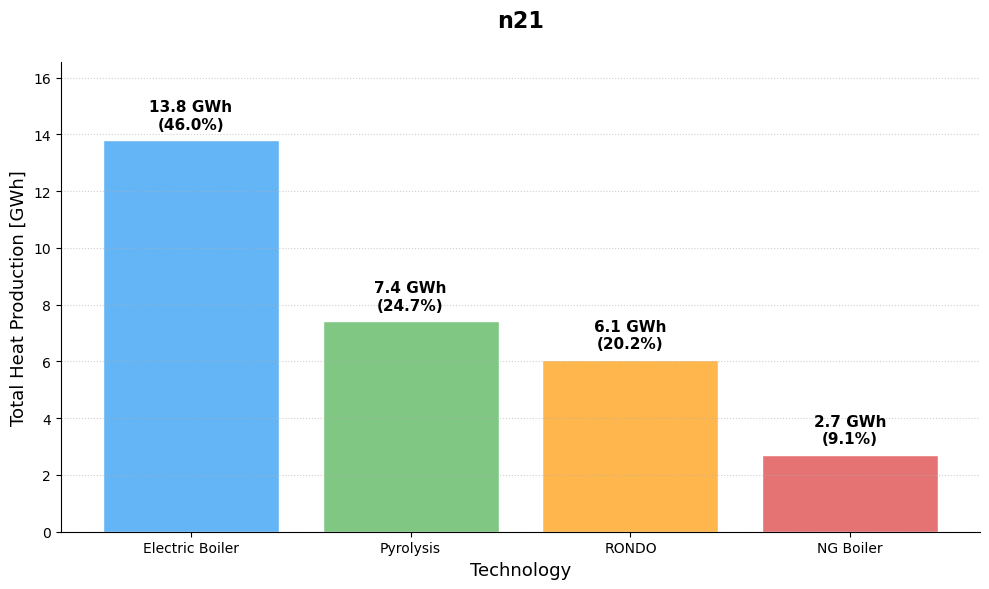

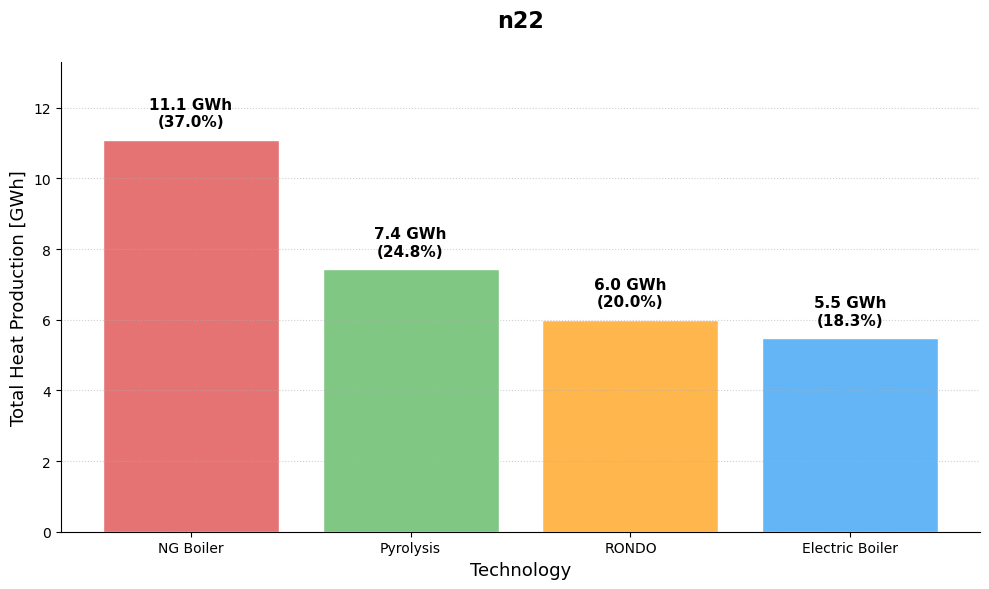

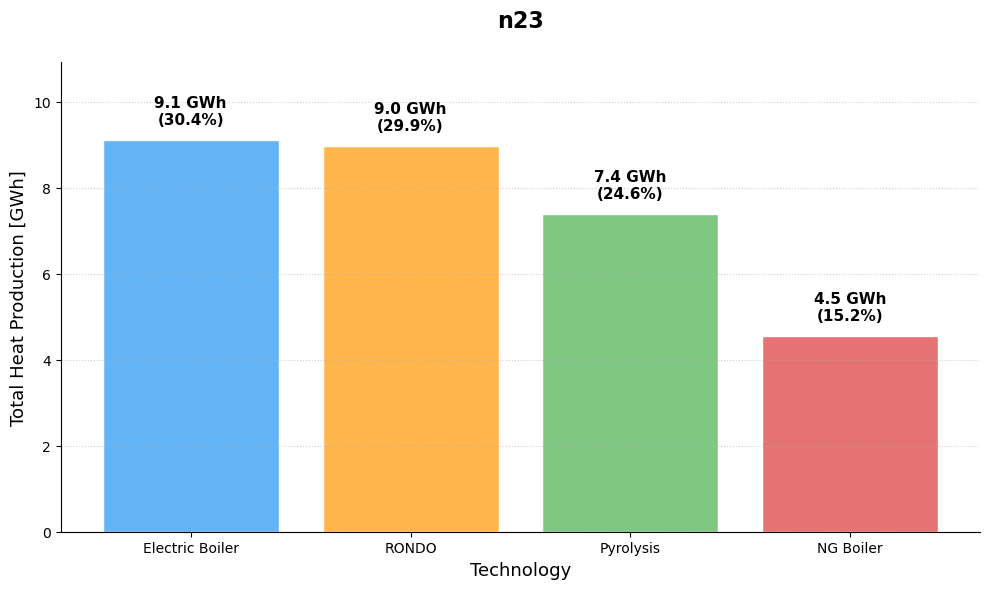

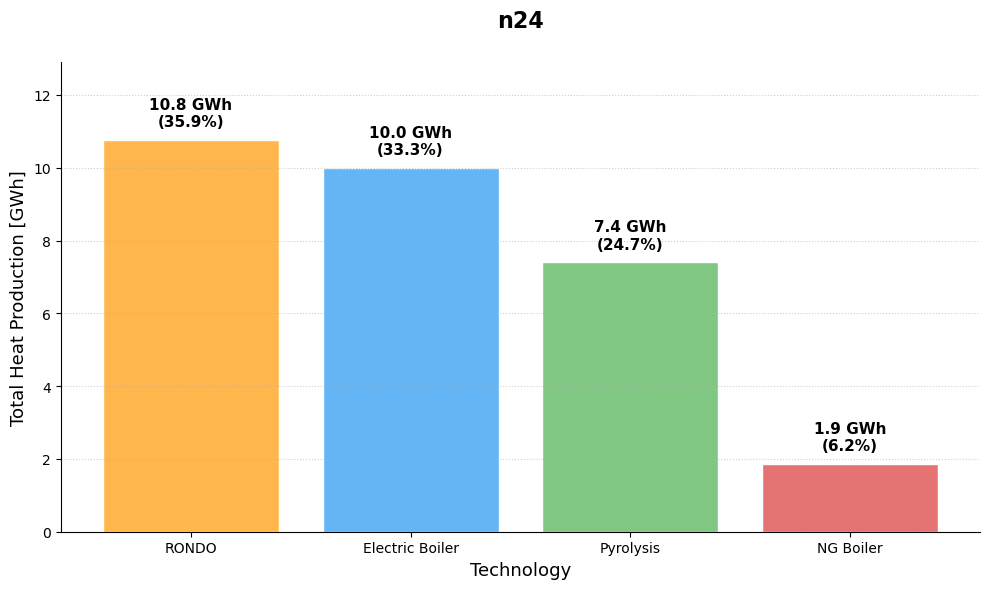

In [153]:
plot_heat_production(n21,title = "n21")
plot_heat_production(n22,title = "n22")
plot_heat_production(n23,title = "n23")
plot_heat_production(n24,title = "n24")

In [154]:
# 2. Generate the topographical image
# You can specify formats like 'png', 'jpg', or 'pdf'
pypsatopo.generate(n21, file_output="network_diagram.png", file_format="png")

[ERR] The tool 'dot' is not installed or could not be found (please visit https://graphviz.org/download to download and install it)!


-1